# StrokeGuard AI — Phase 4: Model Training & Comparison

Goal: train multiple models, compare them honestly using the right metrics, and choose the best one with a clear, defendable reason.

**Reminder:** we train on the balanced training set (from Phase 3), but always evaluate on the untouched, imbalanced test set — because that reflects the real world.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_style('whitegrid')
os.makedirs('../images', exist_ok=True)
os.makedirs('../models', exist_ok=True)


## 1. Load the Processed Data from Phase 3

No need to redo any cleaning — we saved everything already.

In [3]:
data = joblib.load('../data/processed/processed_data.pkl')

X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']
feature_names = data['feature_names']

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (7776, 22)
Test shape: (1022, 22)


## 2. Define the Three Models

- **Logistic Regression** — simple, fast, easy to explain. Good baseline.
- **Random Forest** — an ensemble of decision trees, usually more powerful, harder to fully explain.
- **XGBoost** — a more advanced, often top-performing ensemble method, common in real-world tabular ML.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}


## 3. Train Each Model and Collect Predictions

In [5]:
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    print(f'{name} trained.')


Logistic Regression trained.
Random Forest trained.
XGBoost trained.


## 4. Compare Models — Precision, Recall, F1 (Not Just Accuracy)

**Why not just accuracy:** since only ~5% of test patients actually had a stroke, a model that predicts "no stroke" for everyone would still score ~95% accuracy while being medically useless. Precision and recall tell the real story:
- **Recall** — of all the real stroke cases, how many did we catch? (Missing one is dangerous.)
- **Precision** — of everyone we flagged as high risk, how many actually were? (Too many false alarms erodes trust.)
- **F1** — the balance between the two.

In [6]:
results = []
for name in models.keys():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Precision': precision_score(y_test, predictions[name]),
        'Recall': recall_score(y_test, predictions[name]),
        'F1-Score': f1_score(y_test, predictions[name]),
        'ROC-AUC': roc_auc_score(y_test, probabilities[name])
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7339,0.1325,0.80,0.2273,0.8390
Random Forest,0.9325,0.1724,0.10,0.1266,0.7629
XGBoost,0.9256,0.1750,0.14,0.1556,0.7745


**Your observation:** _(Which model has the best recall? Which has the best precision? Do they agree?)_

> 

## 5. Confusion Matrices — Side by Side

A confusion matrix shows exactly what each model got right and wrong: true positives (caught real strokes), false negatives (missed real strokes — the dangerous ones), false positives (false alarms), true negatives.

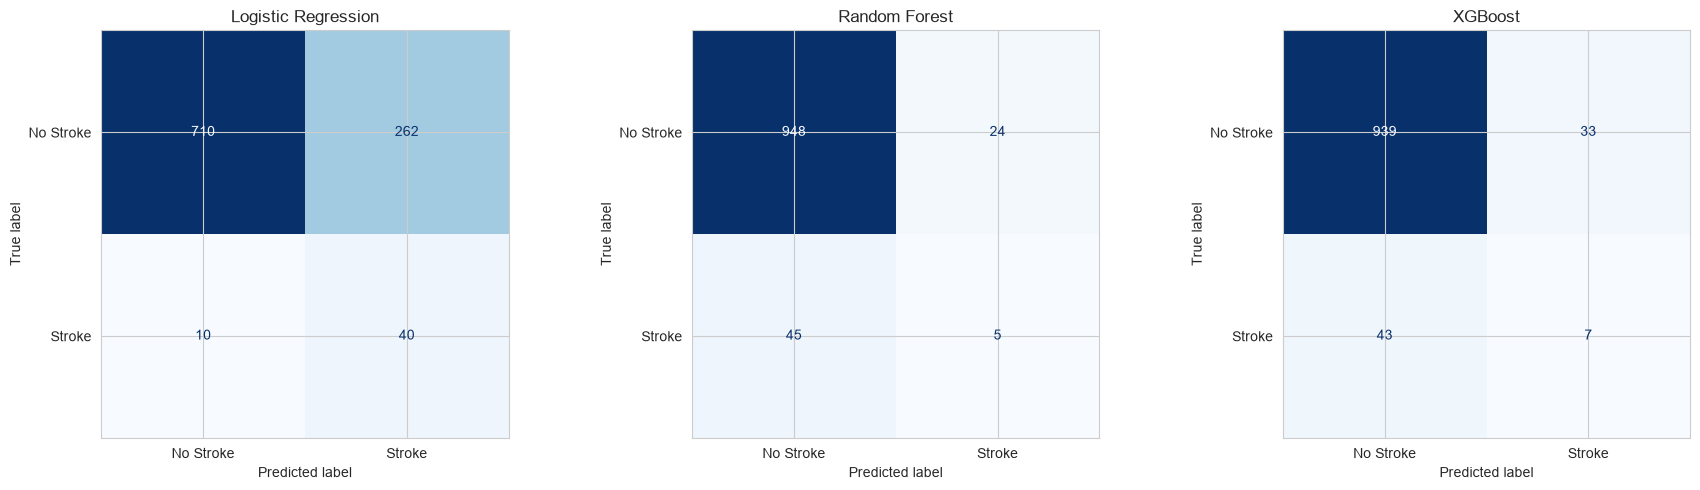

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../images/model_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Which model has the fewest false negatives — missed real stroke cases? That matters most here.)_

> 

## 6. ROC Curves — Overlaid

The ROC curve shows how well each model separates stroke from no-stroke cases across all possible thresholds. The closer the curve hugs the top-left corner, the better. ROC-AUC summarizes this as a single number (1.0 = perfect, 0.5 = random guessing).

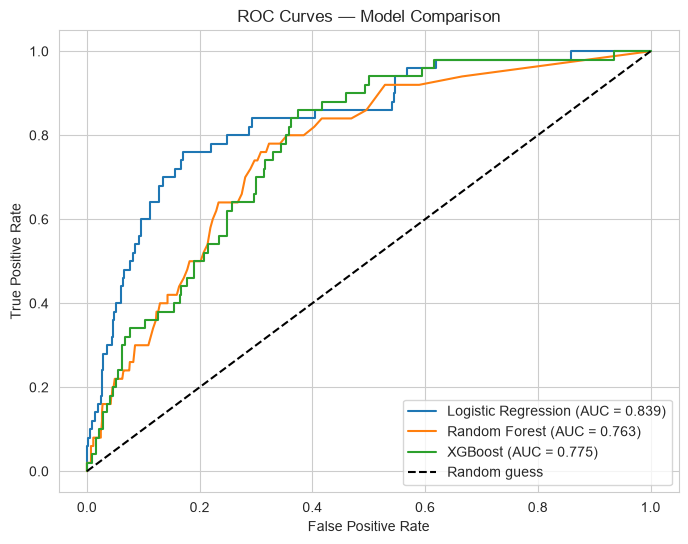

In [8]:
plt.figure(figsize=(8, 6))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.savefig('../images/model_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Which model has the highest AUC? Does this agree with your F1-score ranking?)_

> 

## 7. Choose Your Best Model

This is the most important decision in this notebook — and one you need to be able to defend out loud. Look at the table and charts above, then write your own reasoning below.

Things to think about:
- In a medical risk tool, is missing a real stroke case (low recall) worse than a false alarm (low precision)?
- Is the model with the highest single number always the right practical choice, or does simplicity/explainability matter too?
- Does one model dominate on every metric, or is there a genuine trade-off to justify?

**Write your decision and reasoning here:**

> Best model: 
>
> Reasoning: 

## 8. Save the Best Model

Set `best_model_name` below to match exactly what you wrote above, then run this cell to save it along with a metadata file summarizing your results — both will be used by the Streamlit app in Phase 5.

In [ ]:
best_model_name = 'Logistic Regression'  

best_model = trained_models[best_model_name]
joblib.dump(best_model, '../models/best_stroke_model.pkl')

metadata = {
    'selected_best_model': best_model_name,
    'selection_rationale': 'Write your one-line rationale here, matching what you wrote above.',
    'metrics_summary': results_df.to_dict(orient='index')
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved {best_model_name} as best_stroke_model.pkl')
print('Saved model_metadata.json')


Saved Logistic Regression as best_stroke_model.pkl
Saved model_metadata.json


## Summary

Write 3-4 sentences summarizing your model comparison process and final decision — this becomes presentation material.

- 
- 
- 
- 